<center>

<img src='https://micro.ce.sharif.edu/lib/tpl/writr/images/logo.svg' alt="SUT logo" width=500 height=300 align=center class="saturate" >


<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Intelligent Analysis of Biomedical Images <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Dr. Rohban, Fall 2025 <br>
<font color=3C99D size=5>
    Practical Assignment HW4 - Q1 - Graph Neural Networks <br>
<font color=696880 size=4>
    By: Mohammad Aghaei

</center>


In [4]:
pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import torch
print(torch.__version__)

2.8.0+cpu


In [6]:
pip install torch-scatter -f https://data.pyg.org/whl/torch-2.8.0+cpu.html

Looking in links: https://data.pyg.org/whl/torch-2.8.0+cpu.html
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree
import torch_scatter
import os
from IPython.display import clear_output

Processing...
Done!


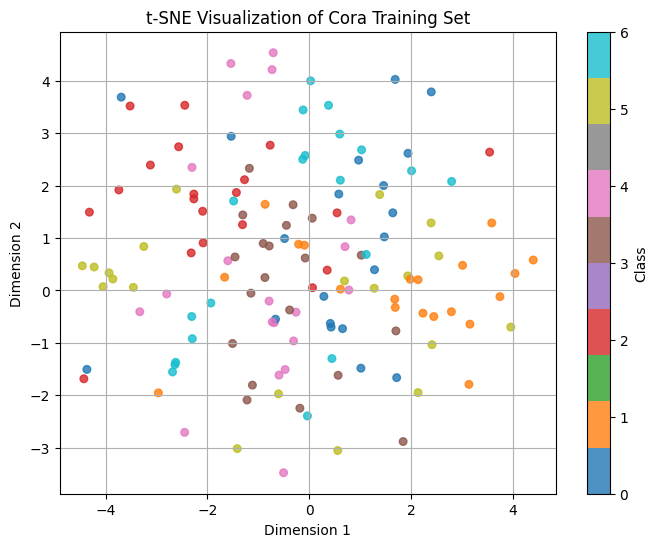

In [8]:
# Load the Cora dataset
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = Planetoid(root='data', name='Cora', transform=NormalizeFeatures())
data = dataset[0]


train_mask = data.train_mask
x_train = data.x[train_mask]  
y_train = data.y[train_mask]  

# Reduce dimensions to 2D using t-SNE
# ========== TODO ==========
tsne = TSNE(n_components=2, random_state=42)
x_train_2d = tsne.fit_transform(x_train.cpu().numpy())
# ==========================
# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(x_train_2d[:, 0], x_train_2d[:, 1], c=y_train.cpu(), cmap='tab10', s=30, alpha=0.8)
plt.colorbar(scatter, label='Class')
plt.title('t-SNE Visualization of Cora Training Set')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)
plt.show()

In [9]:
class GCNConv(MessagePassing):
    def __init__(self, in_channels, out_channels, k=1):
        super(GCNConv, self).__init__(aggr='add')
        self.linear = nn.Linear(in_channels, out_channels)
        self.k = k  # Number of propagation steps (hops)

    def forward(self, x, edge_index):
     # ========== TODO ==========
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))
        row, col = edge_index
        deg = degree(col, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]
        x = self.linear(x)
        for _ in range(self.k):
            x = self.propagate(edge_index, x=x, norm=norm)
        return x
     # ==========================
     
    def propagate(self, edge_index, x, norm):
       # ========== TODO ==========
        row, col = edge_index
        x_j = x[row]
        msg = self.message(x_j, norm)
        aggr_out = self.aggregate(msg, col, dim_size=x.size(0))
        return self.update(aggr_out)
       # ==========================
     

     
    def message(self, x_j, norm):
        # ========== TODO ==========
        return norm.view(-1, 1) * x_j
        # ==========================
         

    def aggregate(self, inputs, index, dim_size=None):
        # ========== TODO ==========
        return torch_scatter.scatter(inputs, index, dim=0, dim_size=dim_size, reduce='add')
        # ==========================

    def update(self, aggr_out):
         # ========== TODO ==========
        return aggr_out
         # ==========================

In [10]:
os.makedirs("tsne_frames", exist_ok=True)

In [11]:
def save_tsne_frame(epoch, model, data):
    model.eval()
    with torch.no_grad():
        # Extract features after first GCN layer
        x = F.relu(model.layers[0](data.x, data.edge_index))
        train_mask = data.train_mask
        x_train = x[train_mask].cpu().numpy()
        y_train = data.y[train_mask].cpu().numpy()

        # Apply t-SNE
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        x_2d = tsne.fit_transform(x_train)

        # Save plot
        plt.figure(figsize=(7, 6))
        scatter = plt.scatter(x_2d[:, 0], x_2d[:, 1], c=y_train, cmap='tab10', s=30, alpha=0.8)
        plt.colorbar(scatter, label='Class')
        plt.title(f't-SNE (Training Set) — Epoch {epoch}')
        plt.xlabel('dim 1')
        plt.ylabel('dim 2')
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"tsne_frames/tsne_epoch_{epoch:03d}.png")
        plt.close()

In [12]:
import matplotlib.animation as animation
from IPython.display import HTML
from PIL import Image

def show_tsne_animation():
    # Load images into frames
    frame_paths = sorted([f"tsne_frames/{f}" for f in os.listdir("tsne_frames") if f.endswith(".png")])
    frames = [Image.open(fp) for fp in frame_paths]

    # Create animation using matplotlib
    fig, ax = plt.subplots(figsize=(7, 6))
    img = plt.imshow(frames[0])
    plt.axis('off')

    def update(i):
        img.set_data(frames[i])
        return [img]

    ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=500)
    plt.close(fig)
    return HTML(ani.to_jshtml())

In [17]:
class StackedGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers):
        super().__init__()
        # ========== TODO ==========
        self.layers = nn.ModuleList()               # ← changed from convs to layers
        if num_layers == 1:
            self.layers.append(GCNConv(in_channels, out_channels))
        else:
            self.layers.append(GCNConv(in_channels, hidden_channels))
            for _ in range(num_layers - 2):
                self.layers.append(GCNConv(hidden_channels, hidden_channels))
            self.layers.append(GCNConv(hidden_channels, out_channels))
        # ==========================

    def forward(self, x, edge_index):
        # ========== TODO ==========
        for i, layer in enumerate(self.layers):     # ← changed from convs to layers
            x = layer(x, edge_index)
            if i < len(self.layers) - 1:
                x = F.relu(x)
        return F.log_softmax(x, dim=1)
        # ==========================

In [14]:
class SingleKHopGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, k):
        super().__init__()
        # ========== TODO ==========
        self.conv = GCNConv(in_channels, hidden_channels, k=k)
        self.out = nn.Linear(hidden_channels, out_channels)
        # ==========================

    def forward(self, x, edge_index):
        # ========== TODO ==========
        x = self.conv(x, edge_index)
        x = F.relu(x)
        x = self.out(x)
        return F.log_softmax(x, dim=1)
        # ==========================

In [18]:
def train(model, data, epoch_num):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)  # TODO filled
    for epoch in range(1, epoch_num + 1):  # usually include the last epoch too
        # ========== TODO ==========
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        # ==========================
        if epoch % 20 == 0:
            save_tsne_frame(epoch, model, data)

def test(model, data):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    correct = pred[data.test_mask] == data.y[data.test_mask]
    return int(correct.sum()) / int(data.test_mask.sum())


K = 2  # Number of layers / hops
hidden_channels = 32


model1 = StackedGCN(
    in_channels=dataset.num_features,
    hidden_channels=hidden_channels,
    out_channels=dataset.num_classes,
    num_layers=K
).to(device)  # TODO filled


# Train the model
train(model1, data, epoch_num=200)

# Evaluate
acc1 = test(model1, data)

print(f"Stacked GCN ({K} layers, k=1 each): Test Accuracy = {acc1:.4f}")
show_tsne_animation()

Stacked GCN (2 layers, k=1 each): Test Accuracy = 0.8070


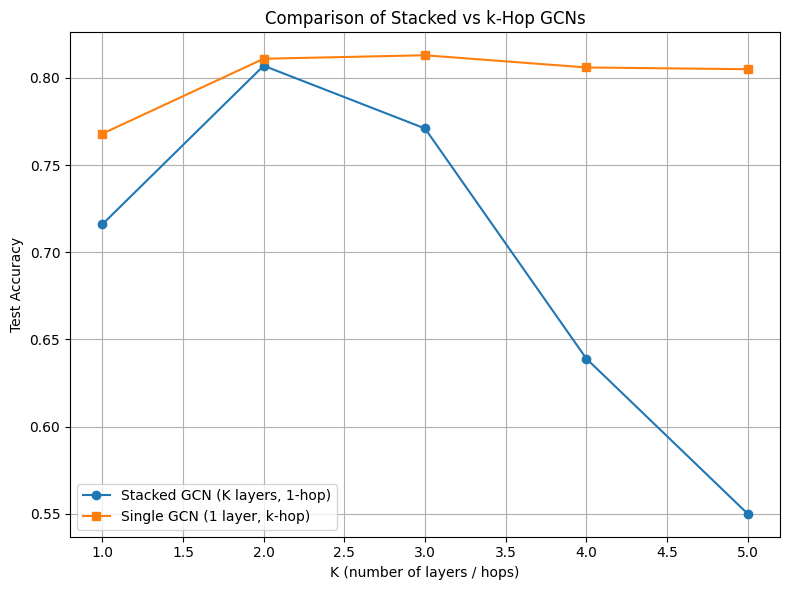

In [19]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

Ks = range(1, 6)
accs_model1 = []
accs_model2 = []

for K in Ks:

        # ========== TODO ==========
        # Stacked GCN: K layers, each 1-hop
        model1 = StackedGCN(
            in_channels=dataset.num_features,
            hidden_channels=32,           # or 16, depending on your earlier choice
            out_channels=dataset.num_classes,
            num_layers=K
        ).to(device)

        optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.01, weight_decay=5e-4)

        model1.train()
        for epoch in range(200):
            optimizer1.zero_grad()
            out = model1(data.x, data.edge_index)
            loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer1.step()

        model1.eval()
        with torch.no_grad():
            out = model1(data.x, data.edge_index)
            pred = out.argmax(dim=1)
            acc1 = (pred[data.test_mask] == data.y[data.test_mask]).float().mean().item()
        accs_model1.append(acc1)

        # Single k-hop GCN: 1 layer with K hops
        model2 = SingleKHopGCN(
            in_channels=dataset.num_features,
            hidden_channels=32,
            out_channels=dataset.num_classes,
            k=K
        ).to(device)

        optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.01, weight_decay=5e-4)

        model2.train()
        for epoch in range(200):
            optimizer2.zero_grad()
            out = model2(data.x, data.edge_index)
            loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer2.step()

        model2.eval()
        with torch.no_grad():
            out = model2(data.x, data.edge_index)
            pred = out.argmax(dim=1)
            acc2 = (pred[data.test_mask] == data.y[data.test_mask]).float().mean().item()
        accs_model2.append(acc2)
        # ==========================

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(Ks, accs_model1, marker='o', label='Stacked GCN (K layers, 1-hop)')
plt.plot(Ks, accs_model2, marker='s', label='Single GCN (1 layer, k-hop)')
plt.xlabel("K (number of layers / hops)")
plt.ylabel("Test Accuracy")
plt.title("Comparison of Stacked vs k-Hop GCNs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()